Running AOA...
Run 1: distance=8720.8, time=2.19s
Run 2: distance=8178.9, time=2.19s
Run 3: distance=8437.4, time=2.62s
Run 4: distance=8379.3, time=2.62s
Run 5: distance=8482.8, time=2.01s
Run 6: distance=7742.6, time=2.46s
Run 7: distance=8198.5, time=2.26s
Run 8: distance=8448.8, time=2.25s
Run 9: distance=8406.3, time=2.28s
Run 10: distance=8520.6, time=2.26s

Running AGWO...
Run 1: distance=8288.5, time=4.39s
Run 2: distance=8264.3, time=3.96s
Run 3: distance=7937.8, time=4.11s
Run 4: distance=8266.4, time=4.11s
Run 5: distance=8488.9, time=3.43s
Run 6: distance=8475.8, time=3.86s
Run 7: distance=8505.7, time=3.83s
Run 8: distance=8095.3, time=3.61s
Run 9: distance=8435.8, time=3.82s
Run 10: distance=8359.7, time=4.36s

Generating plots...


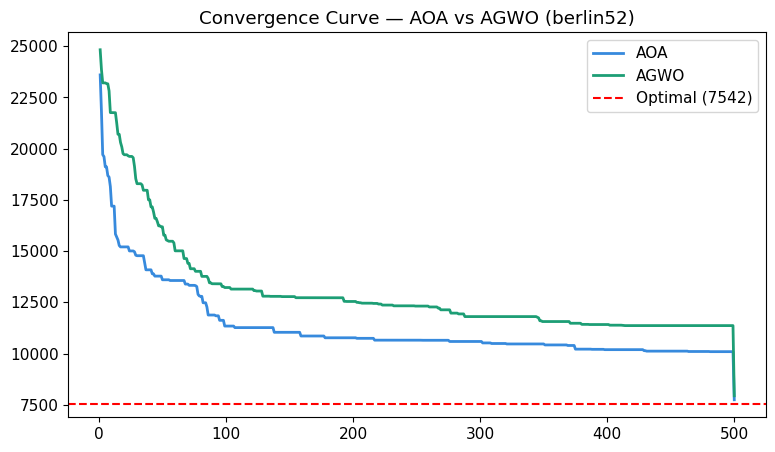

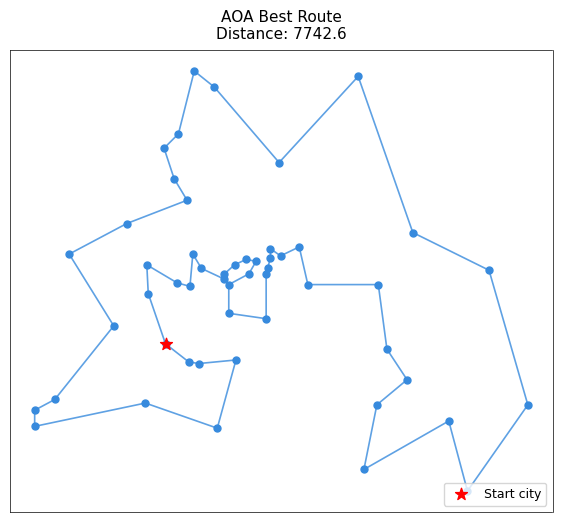

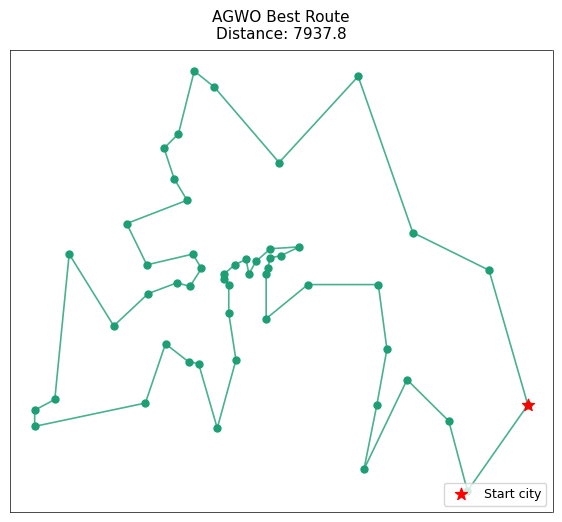

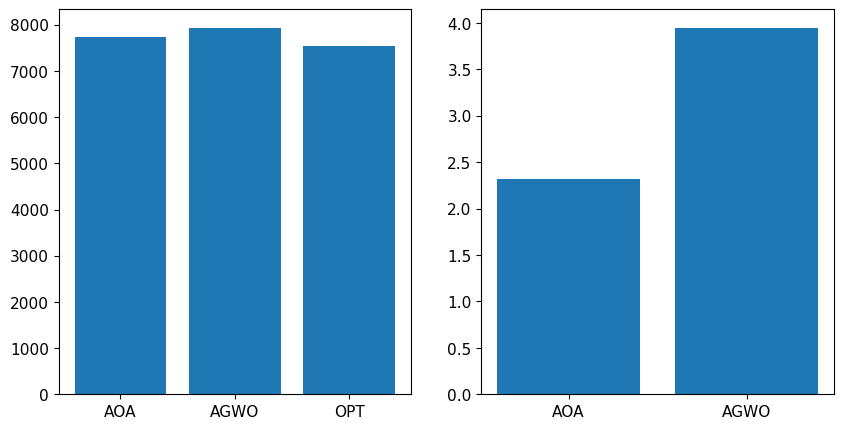

In [2]:
"""
TSP - AOA vs AGWO Comparison
All required visualizations for assignment report
Requirements: pip install numpy matplotlib
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
import random


# ─────────────────────────────────────────────
# TSPLIB DATA LOADER
# ─────────────────────────────────────────────
def load_tsplib(filename):
    coords = []
    with open(filename, 'r') as f:
        start = False
        for line in f:
            if "NODE_COORD_SECTION" in line:
                start = True
                continue
            if "EOF" in line:
                break
            if start:
                parts = line.strip().split()
                if len(parts) == 3:
                    _, x, y = parts
                    coords.append((float(x), float(y)))
    return np.array(coords)


cities = load_tsplib("berlin52.tsp")
N = len(cities)
OPTIMAL = 7542


# ─────────────────────────────────────────────
# DISTANCE HELPERS
# ─────────────────────────────────────────────
def dist(a, b):
    return np.sqrt((cities[a][0]-cities[b][0])**2 + (cities[a][1]-cities[b][1])**2)

def route_length(route):
    return sum(dist(route[i], route[(i+1) % N]) for i in range(N))

def two_opt(route, max_iter=500):
    best = route[:]
    improved = True
    it = 0
    while improved and it < max_iter:
        improved = False
        it += 1
        for i in range(1, N - 1):
            for j in range(i + 1, N):
                new = best[:i] + best[i:j+1][::-1] + best[j+1:]
                if route_length(new) < route_length(best):
                    best = new
                    improved = True
    return best


# ─────────────────────────────────────────────
# ARITHMETIC OPTIMIZATION ALGORITHM (AOA)
# ─────────────────────────────────────────────
def aoa_tsp(n_agents=30, max_iter=500, seed=42):
    np.random.seed(seed)
    random.seed(seed)

    population = [list(np.random.permutation(N)) for _ in range(n_agents)]
    fitness = [route_length(r) for r in population]

    best_idx = np.argmin(fitness)
    best_route = population[best_idx][:]
    best_dist = fitness[best_idx]

    history = []

    for t in range(max_iter):
        MOA = 0.1 + t * ((1 - 0.1) / max_iter)

        for i in range(n_agents):
            r = random.random()

            if r > MOA:
                new_route = best_route[:]
                for _ in range(2):
                    a, b = random.sample(range(N), 2)
                    new_route[a], new_route[b] = new_route[b], new_route[a]
            else:
                new_route = population[i][:]
                a = random.randint(0, N-1)
                b = random.randint(0, N-1)
                city = new_route.pop(a)
                new_route.insert(b, city)

            new_dist = route_length(new_route)

            if new_dist < fitness[i]:
                population[i] = new_route
                fitness[i] = new_dist
                if new_dist < best_dist:
                    best_dist = new_dist
                    best_route = new_route[:]

        history.append(best_dist)

    best_route = two_opt(best_route, max_iter=1000)
    best_dist = route_length(best_route)
    history[-1] = best_dist

    return best_route, best_dist, history


# ─────────────────────────────────────────────
# AGWO (REPLACES GWO ONLY)
# ─────────────────────────────────────────────
def gwo_tsp(n_agents=30, max_iter=500, seed=42):
    n_wolves = n_agents
    np.random.seed(seed)
    random.seed(seed)

    population = [list(np.random.permutation(N)) for _ in range(n_wolves)]
    fitness = [route_length(r) for r in population]

    sorted_idx = np.argsort(fitness)
    alpha_wolf = population[sorted_idx[0]][:]
    beta_wolf  = population[sorted_idx[1]][:]
    delta_wolf = population[sorted_idx[2]][:]
    alpha_fit  = fitness[sorted_idx[0]]

    history = []

    for t in range(max_iter):

        # ── AGWO CHANGE 1: adaptive parameter ──
        a = 2 * (1 - (t / max_iter)**2)

        for i in range(n_wolves):

            # ── AGWO CHANGE 2: weighted leader selection ──
            guide = random.choices(
                [alpha_wolf, beta_wolf, delta_wolf],
                weights=[0.6, 0.3, 0.1]
            )[0]

            new_route = [None] * N
            start, end = sorted(random.sample(range(N), 2))
            new_route[start:end] = guide[start:end]

            remaining = [c for c in population[i] if c not in new_route]
            ptr = 0
            for j in range(N):
                if new_route[j] is None:
                    new_route[j] = remaining[ptr]
                    ptr += 1

            # ── AGWO CHANGE 3: adaptive mutation ──
            if random.random() < (1 - t/max_iter):
                p, q = random.sample(range(N), 2)
                new_route[p], new_route[q] = new_route[q], new_route[p]

            new_dist = route_length(new_route)

            if new_dist < fitness[i]:
                population[i] = new_route
                fitness[i] = new_dist

        sorted_idx = np.argsort(fitness)
        alpha_wolf = population[sorted_idx[0]][:]
        beta_wolf  = population[sorted_idx[1]][:]
        delta_wolf = population[sorted_idx[2]][:]
        alpha_fit  = fitness[sorted_idx[0]]

        history.append(alpha_fit)

    alpha_wolf = two_opt(alpha_wolf, max_iter=1000)
    alpha_fit  = route_length(alpha_wolf)
    history[-1] = alpha_fit

    return alpha_wolf, alpha_fit, history


# ─────────────────────────────────────────────
# MULTIPLE RUNS
# ─────────────────────────────────────────────
def run_multiple(algo_fn, n_runs=10, n_agents=30, max_iter=500):
    results = []
    times = []

    for i in range(n_runs):
        t0 = time.time()
        route, dist_val, hist = algo_fn(n_agents=n_agents, max_iter=max_iter, seed=i*7+13)
        elapsed = time.time() - t0

        results.append((route, dist_val, hist))
        times.append(elapsed)

        print(f"Run {i+1}: distance={dist_val:.1f}, time={elapsed:.2f}s")

    return results, times


# ─────────────────────────────────────────────
# PLOTTING (UNCHANGED)
# ─────────────────────────────────────────────
BLUE  = '#378ADD'
GREEN = '#1D9E75'
GRAY  = '#888780'
plt.rcParams.update({'font.size': 11, 'font.family': 'sans-serif'})

def plot_route(ax, route, color, title, dist_val):
    coords = np.array([cities[r] for r in route] + [cities[route[0]]])
    ax.plot(coords[:,0], coords[:,1], '-', color=color, linewidth=1.2, alpha=0.8)
    ax.scatter(cities[:,0], cities[:,1], s=25, color=color, zorder=5)
    ax.scatter(cities[route[0],0], cities[route[0],1], s=80,
               color='red', zorder=6, marker='*', label='Start city')
    ax.set_title(f"{title}\nDistance: {dist_val:.1f}", fontsize=11, pad=8)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=9, loc='lower right')
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)


def make_all_plots(aoa_results, aoa_times, gwo_results, gwo_times):

    aoa_best_idx = np.argmin([r[1] for r in aoa_results])
    gwo_best_idx = np.argmin([r[1] for r in gwo_results])

    aoa_best_route, aoa_best_dist, aoa_best_hist = aoa_results[aoa_best_idx]
    gwo_best_route, gwo_best_dist, gwo_best_hist = gwo_results[gwo_best_idx]

    aoa_dists = [r[1] for r in aoa_results]
    gwo_dists = [r[1] for r in gwo_results]

    # FIG 1
    fig1, ax = plt.subplots(figsize=(9, 5))
    iters = range(1, len(aoa_best_hist)+1)
    ax.plot(iters, aoa_best_hist, color=BLUE, linewidth=2, label='AOA')
    ax.plot(iters, gwo_best_hist, color=GREEN, linewidth=2, label='AGWO')
    ax.axhline(y=OPTIMAL, color='red', linestyle='--', label=f'Optimal ({OPTIMAL})')
    ax.set_title('Convergence Curve — AOA vs AGWO (berlin52)')
    ax.legend()
    fig1.savefig('fig1_convergence.png')

    # FIG 2
    fig2, ax = plt.subplots(figsize=(7, 6))
    plot_route(ax, aoa_best_route, BLUE, 'AOA Best Route', aoa_best_dist)
    fig2.savefig('fig2_route_aoa.png')

    # FIG 3
    fig3, ax = plt.subplots(figsize=(7, 6))
    plot_route(ax, gwo_best_route, GREEN, 'AGWO Best Route', gwo_best_dist)
    fig3.savefig('fig3_route_gwo.png')

    # FIG 4
    fig4, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].bar(['AOA','AGWO','OPT'], [aoa_best_dist, gwo_best_dist, OPTIMAL])
    axes[1].bar(['AOA','AGWO'], [np.mean(aoa_times), np.mean(gwo_times)])

    fig4.savefig('fig4_comparison.png')

    plt.show()


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────
if __name__ == '__main__':
    N_RUNS = 10
    N_AGENTS = 30
    MAX_ITER = 500

    print("Running AOA...")
    aoa_results, aoa_times = run_multiple(aoa_tsp, N_RUNS, N_AGENTS, MAX_ITER)

    print("\nRunning AGWO...")
    gwo_results, gwo_times = run_multiple(gwo_tsp, N_RUNS, N_AGENTS, MAX_ITER)

    print("\nGenerating plots...")
    make_all_plots(aoa_results, aoa_times, gwo_results, gwo_times)